---
title: "Labels at the end of graphs"
author: "Damien Martin"
date: "2025-11-26 9:59"
categories: [data-vis, plotnine]
image: "image.jpg"
description: "Eliminating the legend and directly labelling the line"
---

# Problem

Can we place labels at the end of lines, so we can avoid a legend altogether?

# Solution

Let's start with a simple dataframe

In [1]:
import pandas as pd
import plotnine as p9

%matplotlib inline 

df = pd.DataFrame(
    {
        'date': pd.date_range('2025-01-01', '2025-01-03'),
        'shirt_sales': [10, 15, 12],
        'pants_sales': [8, 12, 9],
    }
)

df

,date,shirt_sales,pants_sales
0,2025-01-01,10,8
1,2025-01-02,15,12
2,2025-01-03,12,9


For plotnine, we want the data in long format. We will also make a new dataframe with just the end points

In [2]:
long = df.melt(['date'], value_name='sales').sort_values(['variable', 'date'])
last_points = long.groupby('variable').tail(1).assign(label= lambda d: d['variable'].str.replace('_sales', '').str.capitalize())

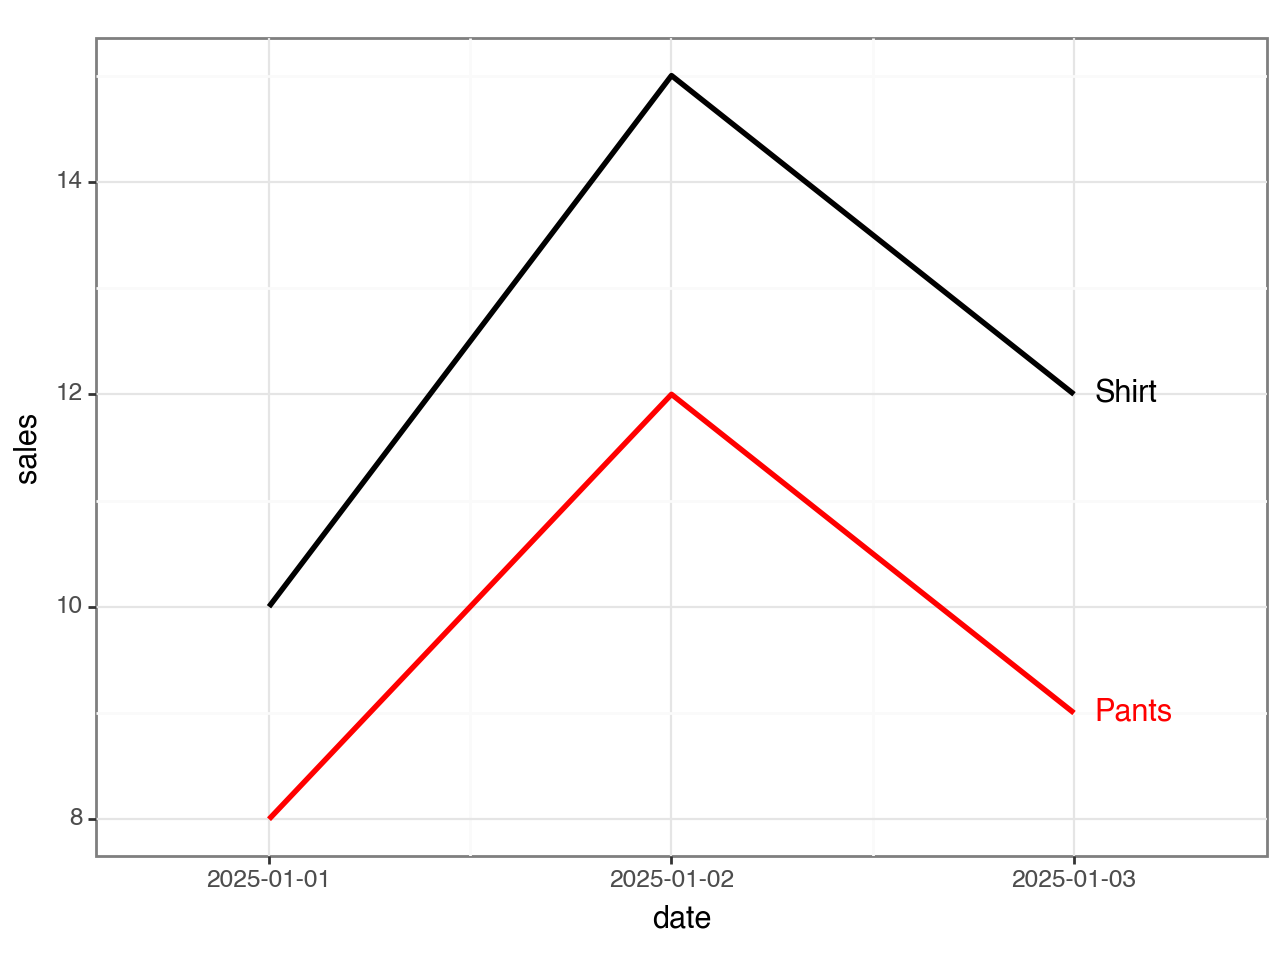

<Figure Size: (640 x 480)>

In [22]:
(
    p9.ggplot(long, p9.aes("date", "sales", color="variable"))
    + p9.geom_line(size=1.1)
    + p9.geom_text(
        data=last_points,
        mapping=p9.aes(label="label"),
        ha="left",
        nudge_x=0.05,
    )
    + p9.scale_color_manual(
        values={"shirt_sales": "black", "pants_sales": "red"}
    )
    + p9.theme_bw()
    + p9.scale_x_date(breaks=df['date'], expand=(0.2, 0.02))
    + p9.theme(legend_position="none")   # hide legend
)

Note that the label extends beyond the edge of the graph, so you will need to play games with the x axis extension.